In [1]:
import torch
import numpy as np
from model_files.SSD_from_scratch import mySSD as newSSD
from model_files.view_preds import show_prediction_side_by_side
from pathlib import Path
from torch.profiler import profile, ProfilerActivity, record_function
from typing import Callable, List, Tuple, Dict, Any, Sequence, Union, Optional, Iterable
import cv2
from dataclasses import dataclass
import time
from __future__ import annotations

import sys
sys.path.append("..")
from SSD_from_scratch import mySSD as oldSSD

# desktop, laptop, ubuntu
machine = 'ubuntu'

# Setup path to data folder
if machine == 'laptop':
    folder_path = Path(r"C:\self-driving-car\data")
elif machine == 'desktop':
    folder_path = Path(r"C:\Udacity_car_data\data")
elif machine == 'ubuntu':
    folder_path = Path(r"/mnt/c/Udacity_car_data/data")

train_path = folder_path / "train"
test_path = folder_path / "test"

In [2]:
# load PyTorch old SSD model
old_ssd = oldSSD(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                          in_channels=3,
                          variances=(0.1, 0.2))
WEIGHTS_PATH = r"/mnt/c/Users/eblac/Documents/GitHub/self-driving-car/app_files/saved_models/noZoomOut_Bootstrap.pth"
# WEIGHTS_PATH = r"C:\Users\eblac\Documents\GitHub\self-driving-car\app_files\saved_models\noZoomOut_Bootstrap.pth"
# WEIGHTS_PATH = r"C:\Users\eblac\OneDrive\Documents\GitHub\self-driving-car\app_files\saved_models\noZoomOut_Bootstrap.pth"
state_dict = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=False)
old_ssd.load_state_dict(state_dict, strict=False)
# old_ssd.to(device='cuda');

<All keys matched successfully>

In [3]:
# load PyTorch new SSD model
new_ssd = newSSD(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                          in_channels=3,
                          variances=(0.1, 0.2))
WEIGHTS_PATH = r"/mnt/c/Users/eblac/Documents/GitHub/self-driving-car/app_files/saved_models/noZoomOut_Bootstrap.pth"
# WEIGHTS_PATH = r"C:\Users\eblac\Documents\GitHub\self-driving-car\app_files\saved_models\noZoomOut_Bootstrap.pth"
# WEIGHTS_PATH = r"C:\Users\eblac\OneDrive\Documents\GitHub\self-driving-car\app_files\saved_models\noZoomOut_Bootstrap.pth"
state_dict = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=False)
new_ssd.load_state_dict(state_dict, strict=False)
# new_ssd.to(device='cuda');

<All keys matched successfully>

In [4]:
# List containing test images
test_list = list(Path(test_path).glob("*.jpg"))

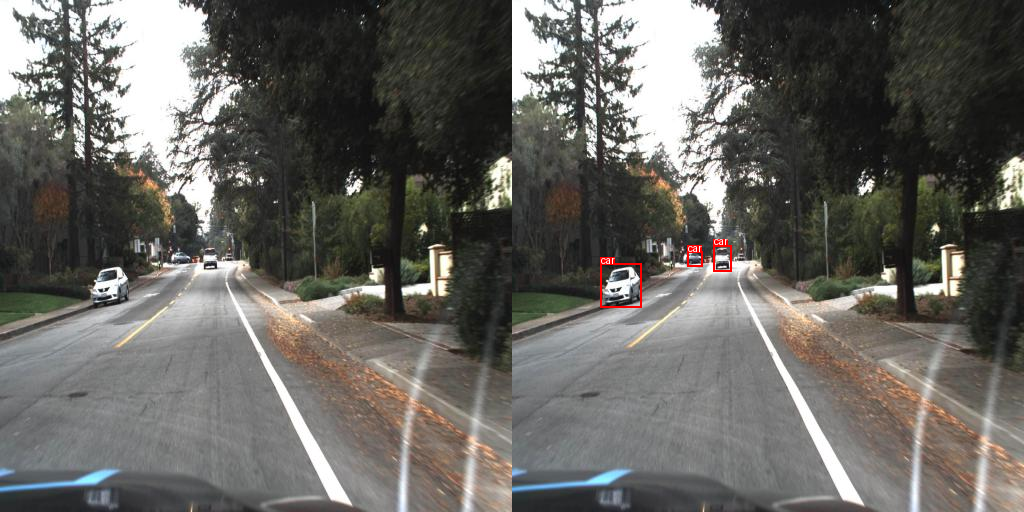

In [15]:
# View some predictions
rand_idx = np.random.randint(0, len(test_list))

old_ssd.show_prediction_side_by_side(image_path=test_list[rand_idx],
                                       pil_img=None,
                                       score_thresh=0.2,
                                       nms_thresh=0.3,
                                       max_per_img=200,
                                       class_agnostic=False,
                                       target_height=512)

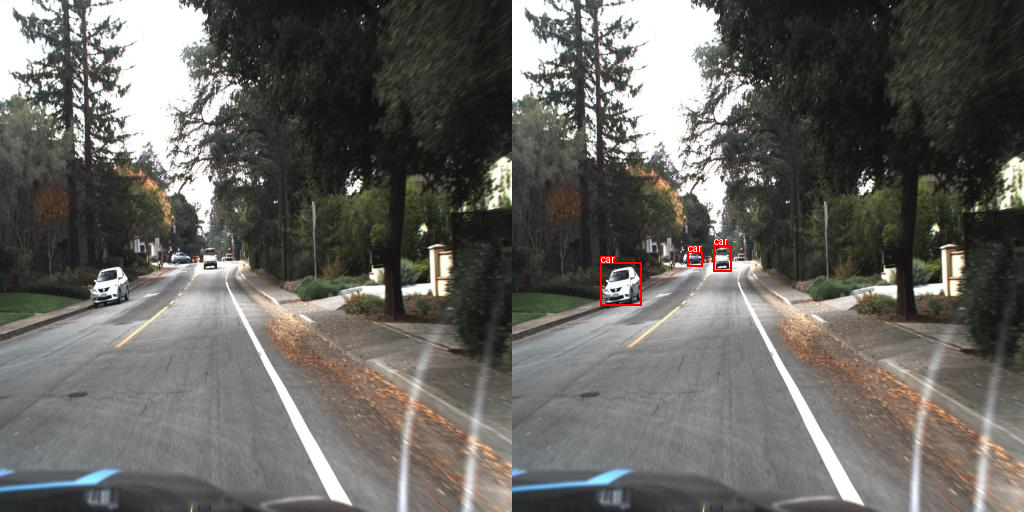

In [16]:
show_prediction_side_by_side(model=new_ssd,
                             image_path=test_list[rand_idx],
                                       pil_img=None,
                                       score_thresh=0.2,
                                       nms_thresh=0.3,
                                       max_per_img=200,
                                       class_agnostic=False,
                                       target_height=512)

In [17]:
# for loading images

def load_images_uint8_chw(
    folder: str,
    *,
    exts=(".jpg", ".jpeg", ".png"),
    limit: int | None = None,
    convert_to_rgb: bool = False,   # keep False if your preprocessing expects BGR
) -> list[np.ndarray]:
    folder = Path(folder)
    paths = sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])
    if limit is not None:
        paths = paths[:limit]

    imgs: list[np.ndarray] = []
    for p in paths:
        im = cv2.imread(str(p), cv2.IMREAD_COLOR)  # uint8 HWC, BGR
        if im is None:
            raise ValueError(f"Failed to read: {p}")
        if convert_to_rgb:
            im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        # enforce contiguous memory (avoids occasional stride surprises)
        im = np.ascontiguousarray(np.transpose(im, (2, 0, 1)))
        imgs.append(im)

    if not imgs:
        raise ValueError(f"No images found in {folder} with extensions {exts}")
    return imgs

# preprocessing function

def preprocess_uint8_chw_rgb(
    x_chw: Union[np.ndarray, torch.Tensor],
    *,
    out_size: Tuple[int, int] = (300, 300),
    mean: Sequence[float] = (0.485, 0.456, 0.406),
    std: Sequence[float]  = (0.229, 0.224, 0.225),
) -> torch.Tensor:
    """
    Input:
        x_chw: uint8 (C,H,W), RGB, values in [0,255]
    Output:
        torch.float32 (1,C,out_H,out_W)

    Equivalent to:
        v2.ToImage()
        v2.ToDtype(torch.float32, scale=True)
        v2.Resize((300,300), antialias=True)
        v2.Normalize(mean=..., std=...)
    """
    # Convert to torch.Tensor
    if isinstance(x_chw, np.ndarray):
        x = torch.from_numpy(x_chw)
    elif isinstance(x_chw, torch.Tensor):
        x = x_chw
    else:
        raise TypeError(f"Expected numpy.ndarray or torch.Tensor, got {type(x_chw)}")

    if x.ndim != 3:
        raise ValueError(f"Expected shape (C,H,W), got {tuple(x.shape)}")
    if x.dtype != torch.uint8:
        raise TypeError(f"Expected dtype uint8, got {x.dtype}")

    # ToDtype(float32, scale=True) for uint8 => /255
    x = x.to(torch.float32) / 255.0

    # Add batch dim: (1,C,H,W)
    x = x.unsqueeze(0)

    # Resize to (300,300) with antialiasing (bilinear like torchvision for tensors)
    try:
        x = torch.nn.functional.interpolate(x, size=out_size, mode="bilinear", align_corners=False, antialias=True)
    except TypeError:
        # Fallback if antialias not supported in your PyTorch version
        x = torch.nn.functional.interpolate(x, size=out_size, mode="bilinear", align_corners=False)

    # Normalize
    mean_t = torch.tensor(mean, dtype=torch.float32, device=x.device).view(1, -1, 1, 1)
    std_t  = torch.tensor(std,  dtype=torch.float32, device=x.device).view(1, -1, 1, 1)
    x = (x - mean_t) / std_t

    return x

In [18]:
# load images
img_list = np.array(load_images_uint8_chw(folder=test_path, convert_to_rgb=True, limit=1000))

In [9]:
with torch.inference_mode():
    with profile(activities=[ProfilerActivity.CPU], record_shapes=True, profile_memory=True) as prof:
        for _ in range(50):
            mi = preprocess_uint8_chw_rgb(img_list[0])
            loc_all, conf_all = old_ssd(mi)
            _ = old_ssd.predict(mi, score_thresh=0.3, nms_thresh=0.5, max_per_img=200, pre_loc_all=loc_all, pre_conf_all=conf_all)

print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=25))

---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
         aten::mkldnn_convolution        84.02%        7.380s        84.41%        7.414s       6.179ms       4.72 GB           0 B          1200  
          aten::native_batch_norm         5.27%     463.252ms         5.43%     477.204ms     477.204us       4.71 GB      -2.83 MB          1000  
    aten::max_pool2d_with_indices         4.19%     367.727ms         4.19%     367.727ms       1.839ms       1.52 GB       1.52 GB           200  
                 aten::clamp_min_         2.86%     250.872ms         2.86%     250.872ms     228.065us         

In [10]:
with torch.inference_mode():
    with profile(activities=[ProfilerActivity.CPU], record_shapes=True, profile_memory=True) as prof:
        for _ in range(50):
            mi = preprocess_uint8_chw_rgb(img_list[0])
            loc_all, conf_all = new_ssd(mi)
            _ = new_ssd.predict(mi, score_thresh=0.3, nms_thresh=0.5, max_per_img=200, pre_loc_all=loc_all, pre_conf_all=conf_all)

print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=25))

---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
         aten::mkldnn_convolution        85.08%        7.365s        85.48%        7.400s       6.166ms       4.72 GB           0 B          1200  
          aten::native_batch_norm         5.00%     432.449ms         5.17%     447.745ms     447.745us       4.71 GB      -2.88 MB          1000  
    aten::max_pool2d_with_indices         4.21%     364.202ms         4.21%     364.202ms       1.821ms       1.52 GB       1.52 GB           200  
                 aten::clamp_min_         2.61%     225.846ms         2.61%     225.846ms     205.315us         

In [14]:
old_ssd.to(device='cuda')

with torch.inference_mode():
    with profile(activities=[ProfilerActivity.CUDA], record_shapes=True, profile_memory=True) as prof:
        for _ in range(50):
            mi = preprocess_uint8_chw_rgb(img_list[0]).to(device='cuda')
            loc_all, conf_all = old_ssd(mi)
            _ = old_ssd.predict(mi, score_thresh=0.3, nms_thresh=0.5, max_per_img=200, pre_loc_all=loc_all, pre_conf_all=conf_all)

print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=25))

[W321 15:00:48.416231436 collection.cpp:1024] Warning: Failed to recover relationship between all profiler and kineto events: 31200 vs. 0  reassociated. (function reassociate)


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                  cudaStreamSynchronize        37.47%     311.595ms        37.47%     311.595ms     479.377us       0.000us         0.00%       0.000us       0.000us           0 B           0 B           0 B           0 

In [15]:
new_ssd.to(device='cuda')

with torch.inference_mode():
    with profile(activities=[ProfilerActivity.CUDA], record_shapes=True, profile_memory=True) as prof:
        for _ in range(50):
            mi = preprocess_uint8_chw_rgb(img_list[0]).to(device='cuda')
            loc_all, conf_all = new_ssd(mi)
            _ = new_ssd.predict(mi, score_thresh=0.3, nms_thresh=0.5, max_per_img=200, pre_loc_all=loc_all, pre_conf_all=conf_all)

print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=25))

[W321 15:01:57.698812021 collection.cpp:1024] Warning: Failed to recover relationship between all profiler and kineto events: 20600 vs. 0  reassociated. (function reassociate)


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                  cudaStreamSynchronize        61.62%     345.583ms        61.62%     345.583ms       1.382ms       0.000us         0.00%       0.000us       0.000us           0 B           0 B           250  
                                       cudaLaunchKernel        21.18%     118.779ms        32.0

In [19]:
def _ms(ns: int) -> float:
    return ns / 1e6

def _pct(sorted_vals: List[float], p: float) -> float:
    # p in [0,100]
    if not sorted_vals:
        return float("nan")
    k = (len(sorted_vals) - 1) * (p / 100.0)
    f = int(k)
    c = min(f + 1, len(sorted_vals) - 1)
    if f == c:
        return sorted_vals[f]
    return sorted_vals[f] + (k - f) * (sorted_vals[c] - sorted_vals[f])

@dataclass
class StageStats:
    n: int
    mean_ms: float
    median_ms: float
    p90_ms: float
    p95_ms: float
    p99_ms: float
    min_ms: float
    max_ms: float

def summarize(times_ms: List[float]) -> StageStats:
    s = sorted(times_ms)
    return StageStats(
        n=len(s),
        mean_ms=sum(s) / len(s),
        median_ms=_pct(s, 50),
        p90_ms=_pct(s, 90),
        p95_ms=_pct(s, 95),
        p99_ms=_pct(s, 99),
        min_ms=s[0],
        max_ms=s[-1],
    )

def bench_inference(
    inputs: Iterable[Any],
    preprocess: Callable[[Any], Any],
    model,
    warmup_iters: int = 20,
    measure_iters: int = 200,
) -> Dict[str, StageStats]:
    """
    CPU-only stage timing with warmup + per-iteration latency distributions.

    inputs: iterable of already-in-memory inputs (e.g., numpy arrays or decoded images)
    preprocess: input -> model_input
    model(x): model_input -> raw_output
    model.predict(x): raw_output -> final_output
    """
    inputs = list(inputs)
    if not inputs:
        raise ValueError("inputs must be non-empty (and already in memory).")

    # --- Warmup (stabilizes caches, allocators, thread pools) ---
    wi = 0
    while wi < warmup_iters:
        x = inputs[wi % len(inputs)]
        mi = preprocess(x)
        loc_all, conf_all = model(mi) # forward(mi)
        _ = model.predict(mi, score_thresh=0.3, nms_thresh=0.5, max_per_img=50, pre_loc_all=loc_all, pre_conf_all=conf_all) # postprocess(ro)
        wi += 1

    pre_t, fwd_t, post_t, e2e_t = [], [], [], []

    # --- Measure ---
    for i in range(measure_iters):
        x = inputs[i % len(inputs)]

        t0 = time.perf_counter_ns()
        mi = preprocess(x)
        t1 = time.perf_counter_ns()
        loc_all, conf_all = model(mi) # forward(mi)
        t2 = time.perf_counter_ns()
        _ = model.predict(mi, score_thresh=0.3, nms_thresh=0.5, max_per_img=50, pre_loc_all=loc_all, pre_conf_all=conf_all) # postprocess(ro)
        t3 = time.perf_counter_ns()

        pre_t.append(_ms(t1 - t0))
        fwd_t.append(_ms(t2 - t1))
        post_t.append(_ms(t3 - t2))
        e2e_t.append(_ms(t3 - t0))

    out = {
        "preprocess": summarize(pre_t),
        "forward": summarize(fwd_t),
        "postprocess": summarize(post_t),
        "end_to_end": summarize(e2e_t),
    }

    # Sanity check: end_to_end should roughly equal sum of stages
    # If not, you probably have hidden work outside the stage calls (or timing overhead dominates).
    sum_means = out["preprocess"].mean_ms + out["forward"].mean_ms + out["postprocess"].mean_ms
    if abs(out["end_to_end"].mean_ms - sum_means) / max(out["end_to_end"].mean_ms, 1e-9) > 0.05:
        print(f"[warn] end_to_end mean ({out['end_to_end'].mean_ms:.3f} ms) != sum of means ({sum_means:.3f} ms).")
        print("       This usually indicates hidden work, extra copies, or stage boundary leakage.")

    return out

def print_report(report: Dict[str, StageStats]) -> None:
    for name, s in report.items():
        print(
            f"{name:>11}: n={s.n:4d}  mean={s.mean_ms:8.3f}  "
            f"p50={s.median_ms:8.3f}  p95={s.p95_ms:8.3f}  p99={s.p99_ms:8.3f}  "
            f"min={s.min_ms:8.3f}  max={s.max_ms:8.3f}"
        )

In [20]:
def bench_inference_gpu(
    inputs: Iterable[Any],
    preprocess: Callable[[Any], Any],
    model,
    warmup_iters: int = 20,
    measure_iters: int = 200,
    device: torch.device | str = "cuda",
    include_h2d_in_preprocess: bool = True,
) -> Dict[str, StageStats]:

    inputs = list(inputs)
    if not inputs:
        raise ValueError("inputs must be non-empty (and already in memory).")

    device = torch.device(device)
    if device.type != "cuda":
        raise ValueError("device must be CUDA for GPU benchmarking.")

    model = model.to(device).eval()

    # Optional: if your model is conv-heavy and input shape is fixed, this often improves GPU speed.
    torch.backends.cudnn.benchmark = True

    # Helper: ensure tensor on GPU
    def to_device(mi):
        # If preprocess returns numpy, convert
        if not torch.is_tensor(mi):
            mi = torch.from_numpy(mi)
        # For non_blocking to matter, mi must be in pinned memory
        return mi.to(device, non_blocking=True)

    # --- Warmup ---
    with torch.inference_mode():
        for wi in range(warmup_iters):
            x = inputs[wi % len(inputs)]
            mi = preprocess(x)
            mi = to_device(mi)

            loc_all, conf_all = model(mi)
            _ = model.predict(
                mi, score_thresh=0.3, nms_thresh=0.5, max_per_img=50,
                pre_loc_all=loc_all, pre_conf_all=conf_all
            )

        # Make sure all warmup GPU work is finished before measurement starts
        torch.cuda.synchronize()

    pre_t, fwd_t, post_t, e2e_t = [], [], [], []

    # Pre-create events to avoid per-iter allocations
    fwd_start = torch.cuda.Event(enable_timing=True)
    fwd_end   = torch.cuda.Event(enable_timing=True)
    post_start = torch.cuda.Event(enable_timing=True)
    post_end   = torch.cuda.Event(enable_timing=True)

    # --- Measure ---
    with torch.inference_mode():
        for i in range(measure_iters):
            x = inputs[i % len(inputs)]

            # PREPROCESS timing: this is CPU wall time (and optionally includes H2D copy)
            t0 = time.perf_counter_ns()
            mi = preprocess(x)
            if include_h2d_in_preprocess:
                mi = to_device(mi)
            t1 = time.perf_counter_ns()

            # FORWARD timing: CUDA events (GPU time)
            if not include_h2d_in_preprocess:
                # If you excluded H2D from preprocess, do it here (but then your "forward" includes transfer).
                mi = to_device(mi)

            fwd_start.record()
            loc_all, conf_all = model(mi)
            fwd_end.record()

            # POST timing: CUDA events (but note: if predict runs on CPU, events won't capture that CPU time)
            post_start.record()
            _ = model.predict(
                mi, score_thresh=0.3, nms_thresh=0.5, max_per_img=50,
                pre_loc_all=loc_all, pre_conf_all=conf_all
            )
            post_end.record()

            # Synchronize so event times are valid and so the next iter doesn't overlap
            torch.cuda.synchronize()
            t3 = time.perf_counter_ns()

            pre_ms = _ms(t1 - t0)
            fwd_ms = fwd_start.elapsed_time(fwd_end)      # milliseconds
            post_ms = post_start.elapsed_time(post_end)   # milliseconds
            e2e_ms = _ms(t3 - t0)  # end-to-end wall time (includes any CPU work inside predict)

            pre_t.append(pre_ms)
            fwd_t.append(fwd_ms)
            post_t.append(post_ms)
            e2e_t.append(e2e_ms)

    out = {
        "preprocess": summarize(pre_t),
        "forward": summarize(fwd_t),
        "postprocess": summarize(post_t),
        "end_to_end": summarize(e2e_t),
    }

    # Sanity check remains useful, but interpret carefully on GPU:
    # - forward/post are GPU-time; preprocess/e2e are CPU wall-time.
    sum_means = out["preprocess"].mean_ms + out["forward"].mean_ms + out["postprocess"].mean_ms
    if abs(out["end_to_end"].mean_ms - sum_means) / max(out["end_to_end"].mean_ms, 1e-9) > 0.10:
        print(f"[warn] end_to_end mean ({out['end_to_end'].mean_ms:.3f} ms) != sum of means ({sum_means:.3f} ms).")
        print("       On GPU this can happen if postprocess has CPU work (NMS in Python/NumPy) or device<->host copies.")

    return out

In [31]:
print("---------- Old model: GPU ----------")
print_report(bench_inference_gpu(inputs=img_list, preprocess=preprocess_uint8_chw_rgb, model=old_ssd, warmup_iters=30, measure_iters=500))
print()

print("---------- New model: GPU ----------")
print_report(bench_inference_gpu(inputs=img_list, preprocess=preprocess_uint8_chw_rgb, model=new_ssd, warmup_iters=30, measure_iters=500))

---------- Old model: GPU ----------
 preprocess: n= 500  mean=   1.216  p50=   1.171  p95=   1.600  p99=   1.866  min=   0.846  max=   3.376
    forward: n= 500  mean=   8.421  p50=   8.413  p95=   8.711  p99=   8.992  min=   8.063  max=  11.242
postprocess: n= 500  mean=   9.716  p50=   8.270  p95=  20.394  p99=  23.735  min=   0.185  max=  24.382
 end_to_end: n= 500  mean=  19.547  p50=  18.101  p95=  30.327  p99=  33.600  min=   9.679  max=  34.209

---------- New model: GPU ----------
 preprocess: n= 500  mean=   1.182  p50=   1.159  p95=   1.393  p99=   1.552  min=   0.849  max=   1.674
    forward: n= 500  mean=   8.333  p50=   8.338  p95=   8.581  p99=   8.675  min=   8.000  max=   8.827
postprocess: n= 500  mean=   1.736  p50=   1.702  p95=   2.141  p99=   2.334  min=   0.171  max=   2.957
 end_to_end: n= 500  mean=  11.443  p50=  11.420  p95=  11.965  p99=  12.363  min=   9.654  max=  12.782


In [22]:
print("---------- Old model: GPU ----------")
print_report(bench_inference_gpu(inputs=img_list, preprocess=preprocess_uint8_chw_rgb, model=old_ssd, warmup_iters=30, measure_iters=500))
print()

print("---------- New model: GPU ----------")
print_report(bench_inference_gpu(inputs=img_list, preprocess=preprocess_uint8_chw_rgb, model=new_ssd, warmup_iters=30, measure_iters=500))

---------- Old model: GPU ----------
 preprocess: n= 500  mean=   0.969  p50=   0.911  p95=   1.284  p99=   1.422  min=   0.570  max=   1.846
    forward: n= 500  mean=   8.202  p50=   8.147  p95=   8.484  p99=   9.546  min=   7.801  max=  13.053
postprocess: n= 500  mean=   8.261  p50=   6.910  p95=  18.139  p99=  20.654  min=   0.152  max=  37.582
 end_to_end: n= 500  mean=  17.632  p50=  16.159  p95=  27.588  p99=  30.107  min=   9.003  max=  51.497

---------- New model: GPU ----------
 preprocess: n= 500  mean=   0.978  p50=   0.963  p95=   1.149  p99=   1.316  min=   0.797  max=   4.022
    forward: n= 500  mean=   8.070  p50=   8.006  p95=   8.290  p99=  12.071  min=   7.686  max=  12.661
postprocess: n= 500  mean=   1.937  p50=   1.827  p95=   2.355  p99=   5.448  min=   0.242  max=  10.339
 end_to_end: n= 500  mean=  11.097  p50=  10.962  p95=  11.630  p99=  18.814  min=   9.057  max=  23.583
